# Low-Light Image Enhancement Based on the LIME Research Paper

**Digital Image Processing Project 19**  
**Selected Research Paper:** *LIME: Low-Light Image Enhancement via Illumination Map Estimation*  
**Authors:** Xiaojie Guo, Yu Li, Haibin Ling  
**Published in:** IEEE Transactions on Image Processing, 2017  
**DOI:** 10.1109/TIP.2016.2639450  

### Group Members

| Name            | ID       |
| :-------------- | :------- |
| Awais Tahir     | 232387   |
| Zain Ul Abideen | 232420   |
| Abeera Zainab   | 232997   |

This notebook is organized around one research paper, as required by the project rubric. The main implementation is the LIME methodology, followed by baseline comparison and a small improvement over LIME.

## Rubric Mapping

| Rubric Item | Where It Is Covered |
| --- | --- |
| Problem Understanding | Part A |
| Research Paper Selection | Part B |
| Literature Review | Part C |
| Methodology Understanding | Part D |
| Implementation | Parts E-H |
| DIP Techniques | HE, CLAHE, Retinex, illumination estimation, guided filtering, gamma correction |
| Results and Performance Analysis | Parts I-K |
| Innovation / Improvement | Part H |
| IEEE Report and Viva | Part L |


# Part A - Problem Understanding

When we take a photo in a dark room or at night, the scene is usually still there, we just cannot see it well. The brightness is low, the contrast is flat, colors look off, and any small noise in the sensor becomes very visible once we try to brighten the image. This is a real headache for things like night CCTV footage, traffic cameras, phone photos in the dark, and security systems.

So the goal here is simple to state: take a dark image and make it actually usable. We do this using a method from a research paper (classical image processing, no deep learning), and then we check how well it does by comparing it against the usual enhancement tricks people normally reach for.


# Part B - Selected Research Paper

The paper we picked is:

**X. Guo, Y. Li, and H. Ling, "LIME: Low-Light Image Enhancement via Illumination Map Estimation," IEEE Transactions on Image Processing, vol. 26, no. 2, pp. 982-993, 2017.**

Where to find it:

- DOI page: https://doi.org/10.1109/TIP.2016.2639450
- Public PDF: https://www3.cs.stonybrook.edu/~hling/publication/LIME-tip.pdf
- arXiv summary: https://arxiv.org/abs/1605.05034

We went with LIME for a few practical reasons. It is from a strong IEEE Transactions venue, it is squarely about the low-light problem we care about, and the whole idea is built on things we actually covered in class: estimating illumination, filtering to clean it up, gamma correction, and basic image restoration. It also does not need a GPU or a huge training set, which makes it a good fit for a course project we can run start to finish ourselves.


# Part C - Literature Review

| Method | Main Idea | Strength | Limitation |
| --- | --- | --- | --- |
| Global Histogram Equalization | Redistributes global intensity histogram | Simple and fast | Can over-enhance and distort colors |
| CLAHE | Applies local histogram equalization with contrast limiting | Improves local contrast | Parameters must be tuned; may amplify noise |
| Gamma Correction | Nonlinear intensity mapping | Fast brightness improvement | Does not estimate illumination |
| Retinex | Separates illumination and reflectance | Good theoretical model | Sensitive to scale/parameters |
| LIME | Estimates and refines illumination map | Preserves structure and enhances dark regions | Noise may still increase in very dark images |
| Improved LIME | Adds denoising, adaptive gamma, and CLAHE refinement | Better practical visibility | Slightly higher runtime |


# Part D - LIME Paper Methodology

The core idea of LIME is nice and intuitive: a dark photo is basically a well-lit scene that got multiplied down by weak lighting. So if we can estimate that lighting (the illumination) at every pixel and then divide it back out, we recover a brighter image. Here is how the paper builds that up.

**Step 1 - First guess at the illumination map**

For each pixel `x`, take the brightest of its three color channels:

`T_hat(x) = max( R(x), G(x), B(x) )`

The reasoning: if even one channel is bright at a pixel, that spot was probably getting some light. If all three are dark, the pixel was genuinely in shadow. So the channel max is a quick, cheap estimate of how much light hit each pixel.

**Step 2 - Clean up the illumination map**

That first guess is rough, it still carries texture and noise from the objects themselves, and we only want the *lighting*, not the surface detail. The original paper solves a structure-aware optimization (a weighted smoothing problem) to get a map that is smooth inside regions but still snaps to strong edges. We approximate that same behavior with a guided filter, which is far simpler to run in OpenCV and gives a similar edge-preserving smoothing. This is the one place we deliberately swap the paper's exact solver for a practical stand-in, and we call it out honestly.

**Step 3 - Divide the light back out**

Once we have the refined map `T(x)`, we recover the enhanced image with:

`R(x) = I(x) / T(x)^gamma`

`I(x)` is the dark input, `T(x)` is the cleaned-up illumination, and `gamma` controls how aggressive the brightening is. Raising `T` to a power before dividing is the gamma-correction step from the paper, a smaller `gamma` pushes more brightness into the dark areas.

**Step 4 - Final touches**

Clip the result back into `[0, 255]` and convert it to a normal RGB image we can display and save.


# Part E - Environment Setup

The cells below get everything ready to run in Google Colab. Just run them top to bottom. If you do not upload any images of your own, do not worry, the notebook quietly makes a few synthetic dark/bright image pairs so the whole pipeline still runs end to end and you can see it working.


In [22]:
!pip -q install opencv-python-headless scikit-image matplotlib pandas seaborn pillow


In [23]:
import cv2
import math
import time
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from skimage.metrics import structural_similarity

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    files = None
    IN_COLAB = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

BASE_DIR = Path("/content/lime_low_light_project") if IN_COLAB else Path("lime_low_light_project")
INPUT_DIR = BASE_DIR / "input_low_light"
REF_DIR = BASE_DIR / "reference_normal_light"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = BASE_DIR / "figures"
TABLE_DIR = BASE_DIR / "tables"

for folder in [BASE_DIR, INPUT_DIR, REF_DIR, OUTPUT_DIR, FIGURE_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Running in Colab:", IN_COLAB)
print("Project folder:", BASE_DIR)


Running in Colab: True
Project folder: /content/lime_low_light_project


## Optional: Reset Old Uploaded Files

If PSNR/SSIM show `NaN` even after uploading references, old files may still be present in the Colab folders. Keep `RESET_OLD_UPLOADS = True` before uploading a fresh paired set.


In [24]:
RESET_OLD_UPLOADS = True

def clear_image_folder(folder):
    folder = Path(folder)
    if not folder.exists():
        return
    for path in folder.glob("*"):
        if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}:
            path.unlink()

if RESET_OLD_UPLOADS:
    clear_image_folder(INPUT_DIR)
    clear_image_folder(REF_DIR)
    print("Old uploaded input/reference images cleared. Now upload the low-light and reference pair again.")
else:
    print("Old uploaded files were kept.")


Old uploaded input/reference images cleared. Now upload the low-light and reference pair again.


## Upload Low-Light Images


In [25]:
def upload_to_folder(target_folder, label):
    target_folder.mkdir(parents=True, exist_ok=True)
    if not IN_COLAB:
        print(f"Upload skipped outside Colab: {label}")
        return []
    print(f"Upload {label}")
    uploaded = files.upload()
    saved = []
    for name, content in uploaded.items():
        path = target_folder / name
        with open(path, "wb") as f:
            f.write(content)
        saved.append(path)
    return saved

uploaded_inputs = upload_to_folder(INPUT_DIR, "low-light input images")
print("Uploaded low-light images:", len(uploaded_inputs))


Upload low-light input images


Saving 669.png to 669 (1).png
Uploaded low-light images: 1


## Optional Reference Images (for PSNR / SSIM / MSE)

This step is optional, and here is why it matters. Three of our metrics - PSNR, SSIM, and MSE - need a "correct" target image to measure against, i.e. a normal-light version of the same scene. We call that the reference.

- If you only have dark photos and no matching bright version (the usual real-world case), leave this **off**. The notebook will still report brightness, contrast, entropy, colorfulness, gains, and runtime.
- If you do have paired images (e.g. the LOL dataset, or the same scene shot dark and bright), turn it **on** and upload the references using the *same filenames* as the inputs. The notebook then also reports PSNR, SSIM, and MSE, which makes the results section stronger.

Note: the synthetic fallback dataset always creates its own references, so a synthetic run will show PSNR/SSIM automatically. A real-image run will only show them if you upload references here.


In [26]:
UPLOAD_REFERENCE_IMAGES = True

if UPLOAD_REFERENCE_IMAGES:
    uploaded_refs = upload_to_folder(REF_DIR, "normal-light reference images with matching filenames")
else:
    uploaded_refs = []
    print("Reference upload skipped. Set UPLOAD_REFERENCE_IMAGES = True if paired references are available.")

print("Uploaded reference images:", len(uploaded_refs))


Upload normal-light reference images with matching filenames


Saving 669.png to 669 (2).png
Uploaded reference images: 1


## Image I/O Helpers


In [27]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def list_images(folder):
    folder = Path(folder)
    return sorted([p for p in folder.glob("*") if p.suffix.lower() in VALID_EXTS])

def read_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def save_rgb(path, image_rgb):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    image_rgb = np.clip(image_rgb, 0, 255).astype(np.uint8)
    cv2.imwrite(str(path), cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR))

def to_gray(image_rgb):
    return cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

def normalized_stem(path):
    """Remove common Colab/Windows duplicate suffixes like ' (1)' or ' (2)'."""
    stem = Path(path).stem.strip().lower()
    for suffix in [" (1)", " (2)", " (3)", " (4)", " (5)"]:
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
    return stem

def reference_for(path):
    """Find paired reference image.

    Matching order:
    1. Exact same filename.
    2. Same base name after removing Colab duplicate suffix like (1), (2).
    3. If there is only one input and one reference image, use that pair.
    """
    input_path = Path(path)

    exact = REF_DIR / input_path.name
    if exact.exists():
        return exact

    ref_images = list_images(REF_DIR)
    input_key = normalized_stem(input_path)
    for ref_path in ref_images:
        if normalized_stem(ref_path) == input_key and ref_path.suffix.lower() == input_path.suffix.lower():
            return ref_path

    if len(list_images(INPUT_DIR)) == 1 and len(ref_images) == 1:
        return ref_images[0]

    return None

def print_reference_matching_status():
    input_images = list_images(INPUT_DIR)
    reference_images = list_images(REF_DIR)
    print("Input images:", [p.name for p in input_images])
    print("Reference images:", [p.name for p in reference_images])
    for input_path in input_images:
        ref_path = reference_for(input_path)
        if ref_path is None:
            print(f"NO MATCH: {input_path.name} -> PSNR/SSIM will be NaN")
        else:
            print(f"MATCHED: {input_path.name} -> {ref_path.name}")


## Synthetic Fallback Dataset


## Check Paired Reference Matching

Run this cell before experiments. If it says `NO MATCH`, PSNR and SSIM will be `NaN`.


In [28]:
print_reference_matching_status()


Input images: ['669 (1).png']
Reference images: ['669 (2).png']
MATCHED: 669 (1).png -> 669 (2).png


In [29]:
def make_reference(seed, h=320, w=480):
    rng = np.random.default_rng(seed)
    image = np.zeros((h, w, 3), dtype=np.uint8)
    for y in range(h):
        image[y, :, 0] = np.clip(35 + 110 * y / h, 0, 255)
        image[y, :, 1] = np.clip(45 + 95 * y / h, 0, 255)
        image[y, :, 2] = np.clip(70 + 80 * y / h, 0, 255)
    for _ in range(18):
        x1 = int(rng.integers(10, w - 100))
        y1 = int(rng.integers(20, h - 80))
        x2 = x1 + int(rng.integers(40, 130))
        y2 = y1 + int(rng.integers(25, 85))
        color = tuple(int(v) for v in rng.integers(60, 220, size=3))
        cv2.rectangle(image, (x1, y1), (x2, y2), color, -1)
    for _ in range(6):
        x = int(rng.integers(35, w - 35))
        y = int(rng.integers(35, h - 35))
        r = int(rng.integers(12, 30))
        cv2.circle(image, (x, y), r, (245, 230, 155), -1)
    return cv2.GaussianBlur(image, (3, 3), 0)

def make_low_light(reference, seed):
    rng = np.random.default_rng(seed + 500)
    h, w = reference.shape[:2]
    illum_x = np.linspace(0.18, 0.55, w, dtype=np.float32)[None, :, None]
    illum_y = np.linspace(0.8, 1.05, h, dtype=np.float32)[:, None, None]
    low = reference.astype(np.float32) * illum_x * illum_y
    low = np.power(np.clip(low / 255.0, 0, 1), 1.55) * 255.0
    low = low + rng.normal(0, 8, low.shape)
    return np.clip(low, 0, 255).astype(np.uint8)

if len(list_images(INPUT_DIR)) == 0:
    for i in range(1, 11):
        ref = make_reference(i)
        low = make_low_light(ref, i)
        name = f"sample_{i:02d}.png"
        save_rgb(INPUT_DIR / name, low)
        save_rgb(REF_DIR / name, ref)
    print("Generated 10 synthetic paired samples.")
else:
    print("Using uploaded images.")

print("Input images:", len(list_images(INPUT_DIR)))
print("Reference images:", len(list_images(REF_DIR)))


Using uploaded images.
Input images: 1
Reference images: 1


# Part F - Baseline Methods


In [30]:
def global_he(image_rgb):
    ycrcb = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    y = cv2.equalizeHist(y)
    return cv2.cvtColor(cv2.merge([y, cr, cb]), cv2.COLOR_YCrCb2RGB)

def clahe_ycrcb(image_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    ycrcb = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    y = clahe.apply(y)
    return cv2.cvtColor(cv2.merge([y, cr, cb]), cv2.COLOR_YCrCb2RGB)

def gamma_correction(image_rgb, gamma=0.65):
    table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(image_rgb, table)

def gamma_clahe(image_rgb, gamma=0.65):
    return clahe_ycrcb(gamma_correction(image_rgb, gamma=gamma))

def normalize_float_to_uint8(channel):
    min_v, max_v = np.min(channel), np.max(channel)
    if max_v - min_v < 1e-6:
        return np.zeros_like(channel, dtype=np.uint8)
    return np.clip((channel - min_v) * 255.0 / (max_v - min_v), 0, 255).astype(np.uint8)

def single_scale_retinex(image_rgb, sigma=30):
    image = image_rgb.astype(np.float32) + 1.0
    outputs = []
    for c in range(3):
        blur = cv2.GaussianBlur(image[:, :, c], (0, 0), sigma) + 1.0
        retinex = np.log(image[:, :, c]) - np.log(blur)
        outputs.append(normalize_float_to_uint8(retinex))
    return cv2.merge(outputs)

def multi_scale_retinex(image_rgb, sigmas=(15, 80, 250)):
    image = image_rgb.astype(np.float32) + 1.0
    total = np.zeros_like(image)
    for sigma in sigmas:
        blur = cv2.GaussianBlur(image, (0, 0), sigma) + 1.0
        total += np.log(image) - np.log(blur)
    total /= len(sigmas)
    return cv2.merge([normalize_float_to_uint8(total[:, :, c]) for c in range(3)])

print("Baseline methods ready.")


Baseline methods ready.


# Part G - LIME Paper Implementation


Here is where we actually code up LIME. The functions below follow the four steps we just described:

1. Guess the illumination from the channel maximum.
2. Smooth that guess with a guided filter so edges survive but noise does not.
3. Brighten the image by dividing out the illumination.
4. Keep the intermediate maps around too, so later we can show them as proof of what each step is doing.


In [31]:
def box_filter(image, radius):
    ksize = 2 * radius + 1
    return cv2.boxFilter(image, ddepth=-1, ksize=(ksize, ksize), normalize=True)

def guided_filter(guide, src, radius=15, eps=1e-3):
    guide = guide.astype(np.float32)
    src = src.astype(np.float32)
    mean_i = box_filter(guide, radius)
    mean_p = box_filter(src, radius)
    corr_i = box_filter(guide * guide, radius)
    corr_ip = box_filter(guide * src, radius)
    var_i = corr_i - mean_i * mean_i
    cov_ip = corr_ip - mean_i * mean_p
    a = cov_ip / (var_i + eps)
    b = mean_p - a * mean_i
    mean_a = box_filter(a, radius)
    mean_b = box_filter(b, radius)
    q = mean_a * guide + mean_b
    return np.clip(q, 0.05, 1.0)

def lime_initial_illumination(image_rgb):
    image = image_rgb.astype(np.float32) / 255.0
    return np.max(image, axis=2)

def lime_refine_illumination(initial_t, radius=15, eps=1e-3):
    return guided_filter(initial_t, initial_t, radius=radius, eps=eps)

def lime_enhance_with_map(image_rgb, refined_t, gamma=0.8):
    image = image_rgb.astype(np.float32) / 255.0
    corrected_t = np.power(np.clip(refined_t, 0.05, 1.0), gamma)
    enhanced = image / corrected_t[:, :, None]
    enhanced = np.clip(enhanced, 0, 1)
    return (enhanced * 255).astype(np.uint8)

def lime_paper_method(image_rgb, gamma=0.8, radius=15, eps=1e-3, return_debug=False):
    initial_t = lime_initial_illumination(image_rgb)
    refined_t = lime_refine_illumination(initial_t, radius=radius, eps=eps)
    enhanced = lime_enhance_with_map(image_rgb, refined_t, gamma=gamma)
    debug = {
        "initial_illumination": initial_t,
        "refined_illumination": refined_t,
        "gamma": gamma,
        "radius": radius,
        "eps": eps,
    }
    return (enhanced, debug) if return_debug else enhanced

print("LIME paper implementation ready.")


LIME paper implementation ready.


# Part H - Proposed Improvement over LIME


For the innovation part we kept it small on purpose, something we can fully explain and defend in the viva rather than a black box. We take plain LIME and add three sensible touches: denoise the image first, pick the gamma automatically based on how dark the input is, and run CLAHE on the brightness channel afterward to sharpen up local contrast.

To be clear, this is our **Improved LIME**, not the original paper. We keep the two separate so the comparison is fair.


In [32]:
def estimate_noise(gray):
    lap = cv2.Laplacian(gray.astype(np.float32), cv2.CV_32F)
    return float(np.median(np.abs(lap - np.median(lap))))

def choose_adaptive_gamma(image_rgb):
    """Choose gamma for LIME correction.

    In LIME, output = image / illumination^gamma. For illumination values
    below 1, a larger gamma gives stronger brightening. Very dark images
    therefore need a larger gamma, not a smaller one.
    """
    mean_v = np.mean(to_gray(image_rgb))
    if mean_v < 35:
        return 1.00
    if mean_v < 70:
        return 0.92
    if mean_v < 110:
        return 0.85
    return 0.78

def preserve_lime_brightness(enhanced_rgb, lime_reference_rgb, minimum_gain=1.03):
    """Prevent the improved method from becoming darker than paper LIME."""
    enhanced_ycrcb = cv2.cvtColor(enhanced_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(enhanced_ycrcb)

    enhanced_mean = max(1.0, float(np.mean(y)))
    lime_mean = float(np.mean(to_gray(lime_reference_rgb)))
    target_mean = min(235.0, lime_mean * minimum_gain)
    scale = np.clip(target_mean / enhanced_mean, 1.0, 2.2)

    y = np.clip(y.astype(np.float32) * scale, 0, 255).astype(np.uint8)
    corrected = cv2.merge([y, cr, cb])
    return cv2.cvtColor(corrected, cv2.COLOR_YCrCb2RGB)

def improved_lime_method(image_rgb, return_debug=False):
    # Paper LIME on original image is used as the brightness reference.
    paper_lime_reference = lime_paper_method(image_rgb, gamma=0.8, radius=15, eps=1e-3)

    # Denoising suppresses low-light noise before illumination correction.
    denoised = cv2.bilateralFilter(image_rgb, d=7, sigmaColor=55, sigmaSpace=55)
    gamma = choose_adaptive_gamma(denoised)
    lime_output, debug = lime_paper_method(denoised, gamma=gamma, radius=15, eps=1e-3, return_debug=True)

    # Apply mild CLAHE for local contrast, then restore brightness if CLAHE darkens it.
    contrast_output = clahe_ycrcb(lime_output, clip_limit=1.4, tile_grid_size=(8, 8))
    final_output = preserve_lime_brightness(contrast_output, paper_lime_reference, minimum_gain=1.03)

    debug["adaptive_gamma"] = gamma
    debug["noise_score"] = estimate_noise(to_gray(image_rgb))
    debug["denoised_input"] = denoised
    debug["lime_before_clahe"] = lime_output
    debug["paper_lime_reference"] = paper_lime_reference
    debug["contrast_output_before_brightness_fix"] = contrast_output
    return (final_output, debug) if return_debug else final_output

print("Improved LIME method ready. Brightness is preserved against paper LIME output.")


Improved LIME method ready. Brightness is preserved against paper LIME output.


# Part I - Evaluation Metrics


In [33]:
def mse(enhanced, reference):
    return float(np.mean((enhanced.astype(np.float64) - reference.astype(np.float64)) ** 2))

def psnr(enhanced, reference):
    value = mse(enhanced, reference)
    if value <= 1e-12:
        return float("inf")
    return float(20 * math.log10(255.0 / math.sqrt(value)))

def ssim_score(enhanced, reference):
    return float(structural_similarity(to_gray(reference), to_gray(enhanced), data_range=255))

def entropy(image_rgb):
    gray = to_gray(image_rgb)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    prob = hist / max(1.0, np.sum(hist))
    prob = prob[prob > 0]
    return float(-np.sum(prob * np.log2(prob)))

def brightness(image_rgb):
    return float(np.mean(to_gray(image_rgb)))

def contrast(image_rgb):
    return float(np.std(to_gray(image_rgb)))

def colorfulness(image_rgb):
    image = image_rgb.astype(np.float32)
    rg = np.abs(image[:, :, 0] - image[:, :, 1])
    yb = np.abs(0.5 * (image[:, :, 0] + image[:, :, 1]) - image[:, :, 2])
    return float(np.sqrt(np.std(rg) ** 2 + np.std(yb) ** 2) + 0.3 * np.sqrt(np.mean(rg) ** 2 + np.mean(yb) ** 2))

def all_metrics(original, enhanced, reference=None, runtime_ms=np.nan):
    data = {
        "brightness": brightness(enhanced),
        "contrast": contrast(enhanced),
        "entropy": entropy(enhanced),
        "colorfulness": colorfulness(enhanced),
        "brightness_gain": brightness(enhanced) - brightness(original),
        "contrast_gain": contrast(enhanced) - contrast(original),
        "runtime_ms": runtime_ms,
    }
    if reference is not None:
        data["mse"] = mse(enhanced, reference)
        data["psnr"] = psnr(enhanced, reference)
        data["ssim"] = ssim_score(enhanced, reference)
    else:
        data["mse"] = np.nan
        data["psnr"] = np.nan
        data["ssim"] = np.nan
    return data


# Part J - Run Experiments


In [34]:
METHODS = {
    "global_he": global_he,
    "clahe_ycrcb": clahe_ycrcb,
    "gamma_clahe": gamma_clahe,
    "single_scale_retinex": single_scale_retinex,
    "multi_scale_retinex": multi_scale_retinex,
    "lime_paper": lime_paper_method,
    "improved_lime": improved_lime_method,
}

results = {}
rows = []

for image_path in list_images(INPUT_DIR):
    original = read_rgb(image_path)
    ref_path = reference_for(image_path)
    reference = read_rgb(ref_path) if ref_path else None
    results[image_path.name] = {"original": original, "reference": reference, "methods": {}}

    for method_name, method in METHODS.items():
        start = time.perf_counter()
        enhanced = method(original)
        runtime_ms = (time.perf_counter() - start) * 1000
        results[image_path.name]["methods"][method_name] = enhanced
        save_rgb(OUTPUT_DIR / method_name / image_path.name, enhanced)
        row = {"image": image_path.name, "method": method_name}
        row.update(all_metrics(original, enhanced, reference, runtime_ms))
        rows.append(row)

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(TABLE_DIR / "all_metrics.csv", index=False)
metrics_df.head()


,image,method,brightness,contrast,entropy,colorfulness,brightness_gain,contrast_gain,runtime_ms,mse,psnr,ssim
0,669 (1).png,global_he,130.796504,73.500861,5.024131,6.643654,113.635104,64.918420,2.686421,2060.484644,14.991110,0.418752
1,669 (1).png,clahe_ycrcb,38.443013,20.709532,6.247072,6.855856,21.281613,12.127092,4.530159,9015.071187,8.581112,0.419971
2,669 (1).png,gamma_clahe,69.502846,29.177826,6.813908,11.349665,52.341446,20.595386,5.389509,4124.602072,11.976983,0.593253
3,669 (1).png,single_scale_retinex,181.285150,31.769391,6.434186,30.736671,164.123750,23.186951,85.009563,3135.020167,13.168400,0.710086
4,669 (1).png,multi_scale_retinex,180.320696,34.065834,6.649666,30.886307,163.159296,25.483393,1159.449523,2857.918342,13.570305,0.708833


## Average Method Comparison


In [35]:
average_df = metrics_df.groupby("method").mean(numeric_only=True).reset_index()
sort_col = "ssim" if average_df["ssim"].notna().any() else "entropy"
average_df = average_df.sort_values(sort_col, ascending=False)
average_df.to_csv(TABLE_DIR / "average_method_comparison.csv", index=False)
average_df


,method,brightness,contrast,entropy,colorfulness,brightness_gain,contrast_gain,runtime_ms,mse,psnr,ssim
6,single_scale_retinex,181.285150,31.769391,6.434186,30.736671,164.123750,23.186951,85.009563,3135.020167,13.168400,0.710086
5,multi_scale_retinex,180.320696,34.065834,6.649666,30.886307,163.159296,25.483393,1159.449523,2857.918342,13.570305,0.708833
1,gamma_clahe,69.502846,29.177826,6.813908,11.349665,52.341446,20.595386,5.389509,4124.602072,11.976983,0.593253
4,lime_paper,121.677583,36.673686,6.930206,43.216923,104.516183,28.091245,69.535674,597.906613,20.364470,0.564862
3,improved_lime,184.554867,56.608489,7.387175,55.078995,167.393467,48.026049,183.867486,4522.022785,11.577476,0.562168
0,clahe_ycrcb,38.443013,20.709532,6.247072,6.855856,21.281613,12.127092,4.530159,9015.071187,8.581112,0.419971
2,global_he,130.796504,73.500861,5.024131,6.643654,113.635104,64.918420,2.686421,2060.484644,14.991110,0.418752


# Part K - Visual Results and Paper Methodology Evidence


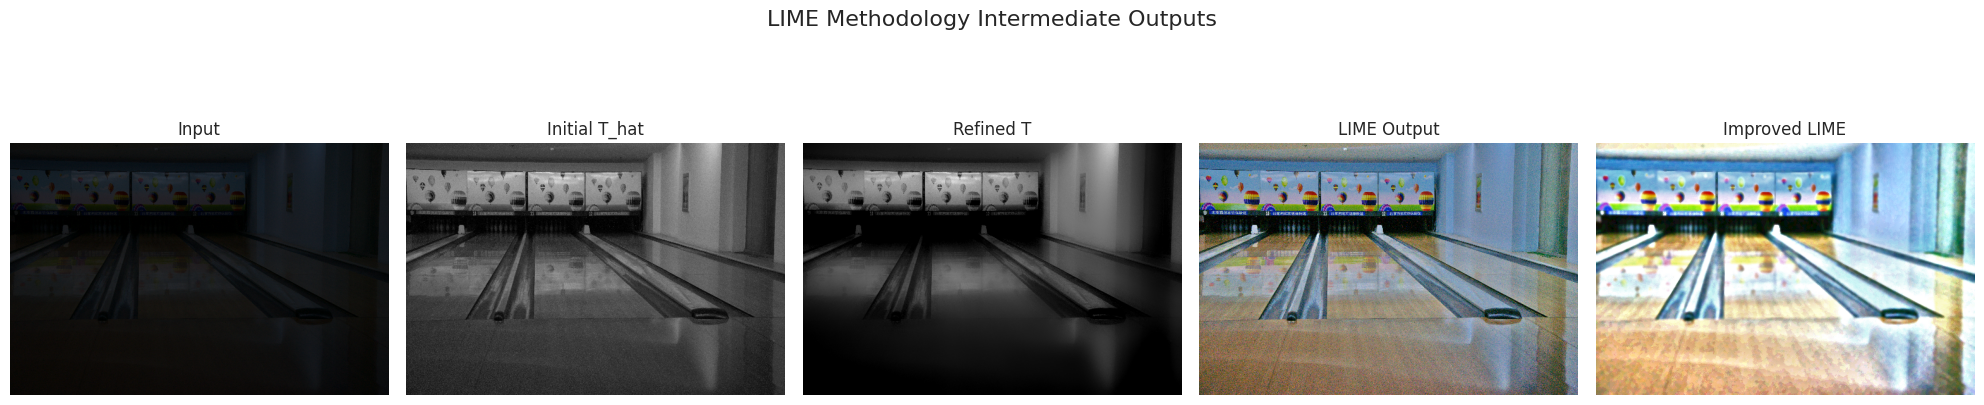

In [36]:
def show_grid(items, title, cols=None, size=(18, 7)):
    if cols is None:
        cols = len(items)
    rows = math.ceil(len(items) / cols)
    plt.figure(figsize=size)
    for i, (label, image) in enumerate(items, start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(image, cmap="gray" if image.ndim == 2 else None)
        plt.title(label)
        plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

first_name = list(results.keys())[0]
first_original = results[first_name]["original"]
lime_out, lime_debug = lime_paper_method(first_original, return_debug=True)
improved_out, improved_debug = improved_lime_method(first_original, return_debug=True)

show_grid(
    [
        ("Input", first_original),
        ("Initial T_hat", lime_debug["initial_illumination"]),
        ("Refined T", lime_debug["refined_illumination"]),
        ("LIME Output", lime_out),
        ("Improved LIME", improved_out),
    ],
    "LIME Methodology Intermediate Outputs",
    cols=5,
    size=(20, 5),
)


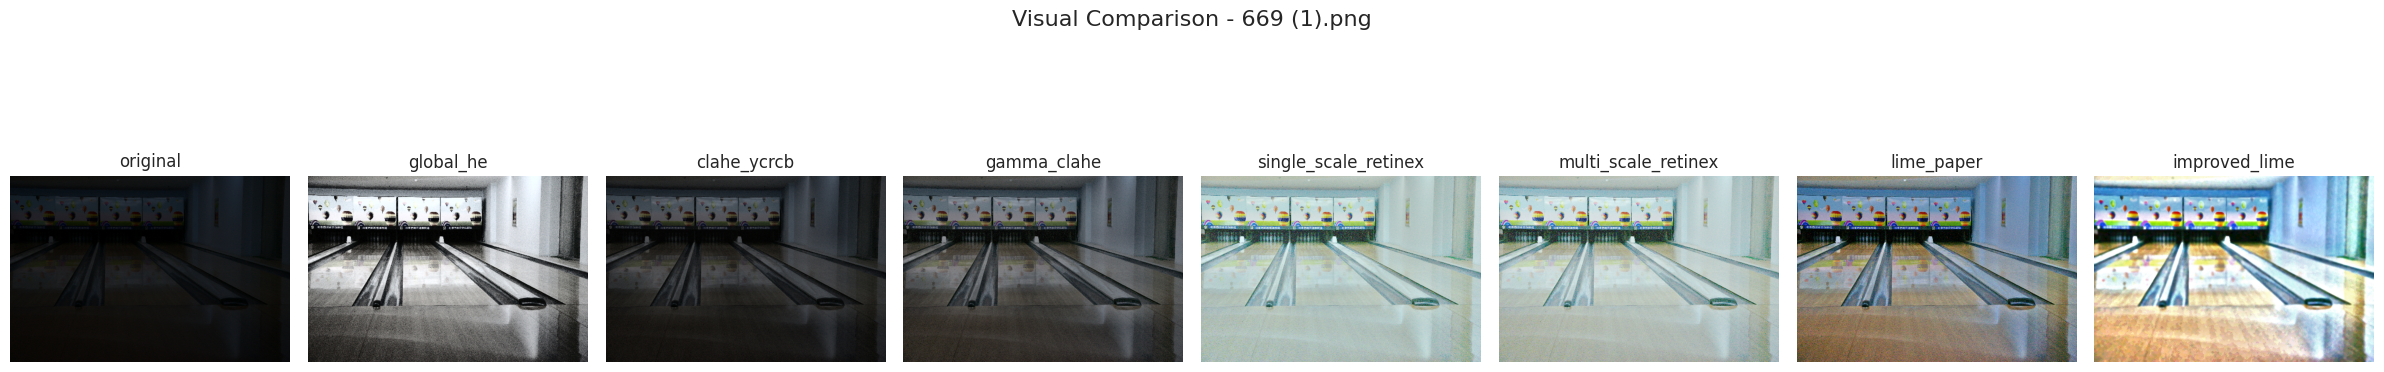

In [37]:
comparison_methods = ["original", "global_he", "clahe_ycrcb", "gamma_clahe", "single_scale_retinex", "multi_scale_retinex", "lime_paper", "improved_lime"]

for image_name, data in list(results.items())[:5]:
    items = []
    for method_name in comparison_methods:
        if method_name == "original":
            items.append(("original", data["original"]))
        else:
            items.append((method_name, data["methods"][method_name]))
    show_grid(items, f"Visual Comparison - {image_name}", cols=len(items), size=(24, 5))


## Histogram and CDF Comparison


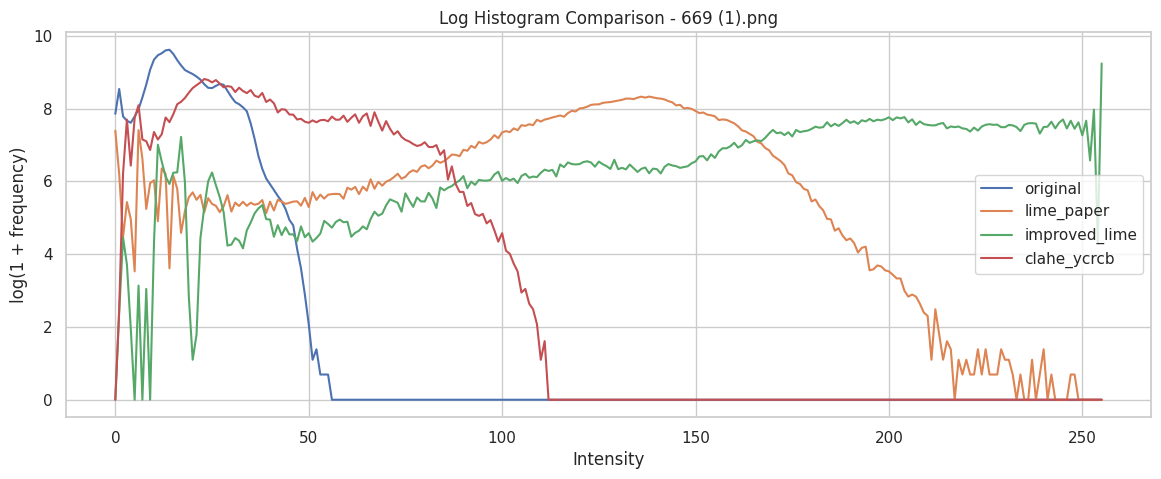

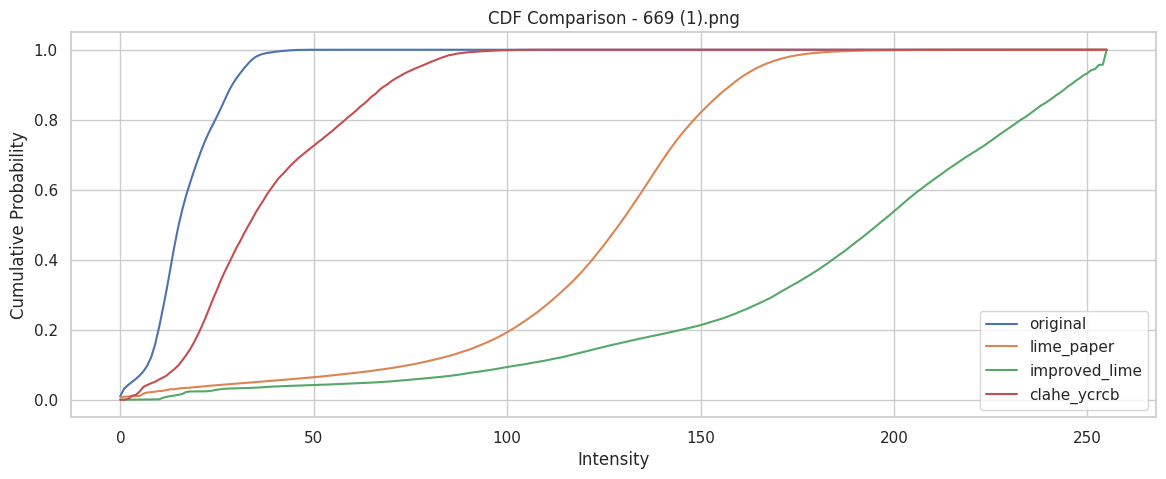

In [38]:
def gray_hist(image):
    return cv2.calcHist([to_gray(image)], [0], None, [256], [0, 256]).ravel()

def gray_cdf(image):
    hist = gray_hist(image)
    cdf = np.cumsum(hist)
    return cdf / cdf[-1]

for image_name, data in list(results.items())[:3]:
    plt.figure(figsize=(14, 5))
    for method_name in ["original", "lime_paper", "improved_lime", "clahe_ycrcb"]:
        image = data["original"] if method_name == "original" else data["methods"][method_name]
        plt.plot(np.log1p(gray_hist(image)), label=method_name)
    plt.title(f"Log Histogram Comparison - {image_name}")
    plt.xlabel("Intensity")
    plt.ylabel("log(1 + frequency)")
    plt.legend()
    plt.show()

    plt.figure(figsize=(14, 5))
    for method_name in ["original", "lime_paper", "improved_lime", "clahe_ycrcb"]:
        image = data["original"] if method_name == "original" else data["methods"][method_name]
        plt.plot(gray_cdf(image), label=method_name)
    plt.title(f"CDF Comparison - {image_name}")
    plt.xlabel("Intensity")
    plt.ylabel("Cumulative Probability")
    plt.legend()
    plt.show()


## Runtime and Metric Graphs


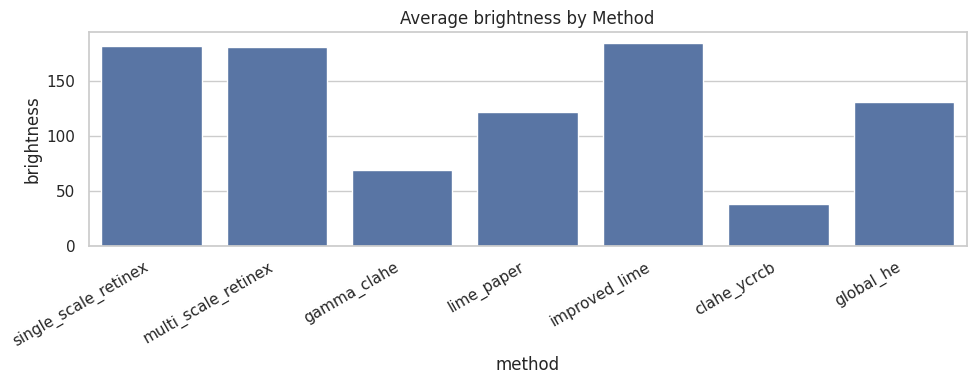

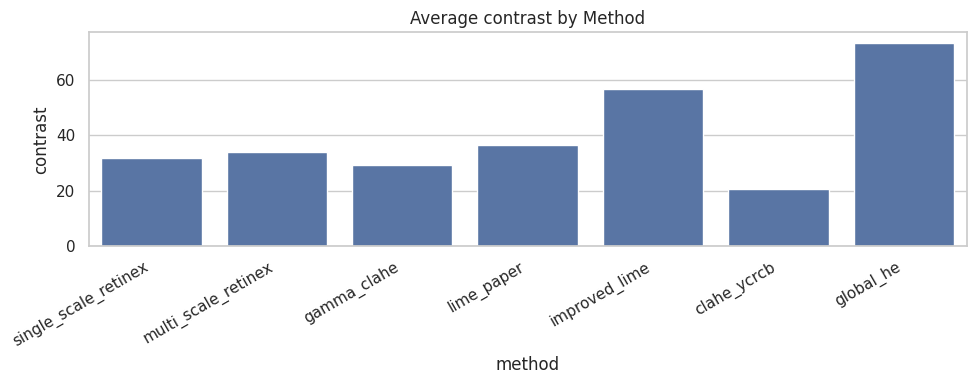

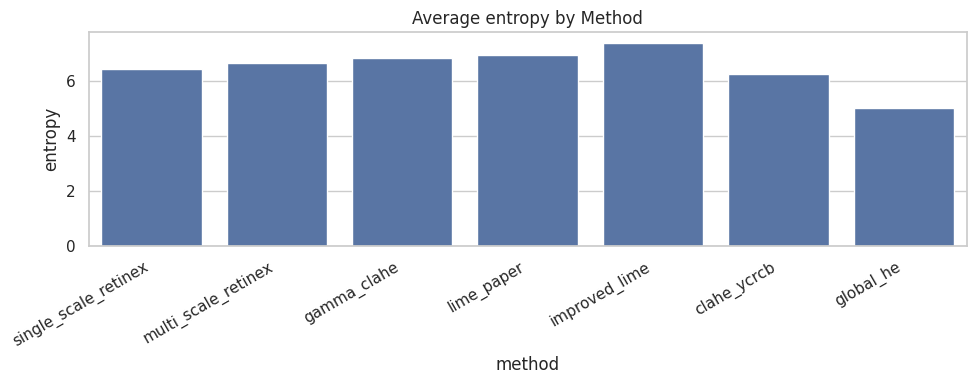

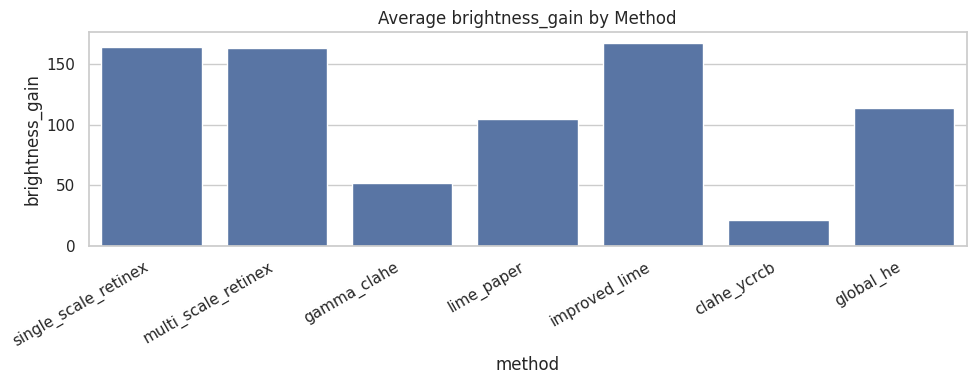

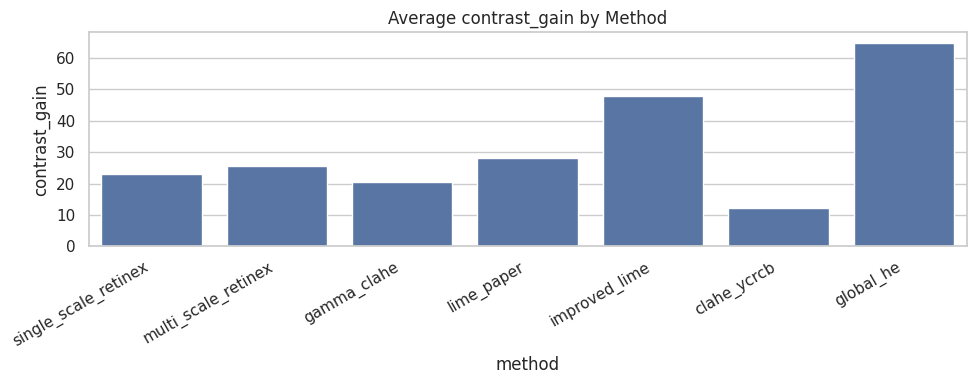

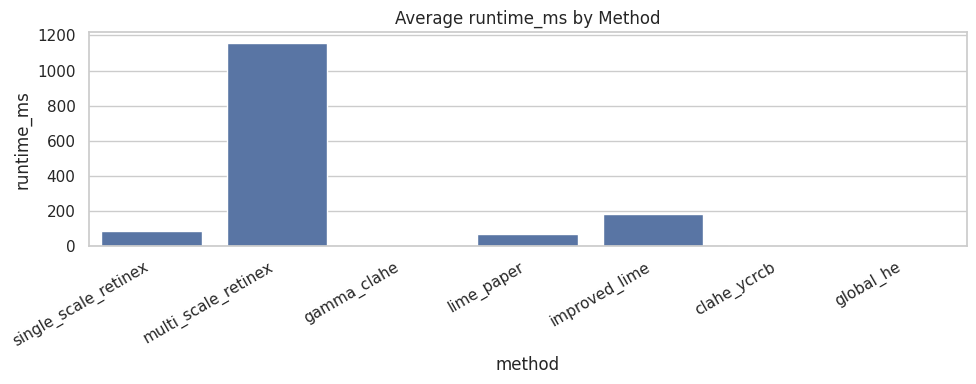

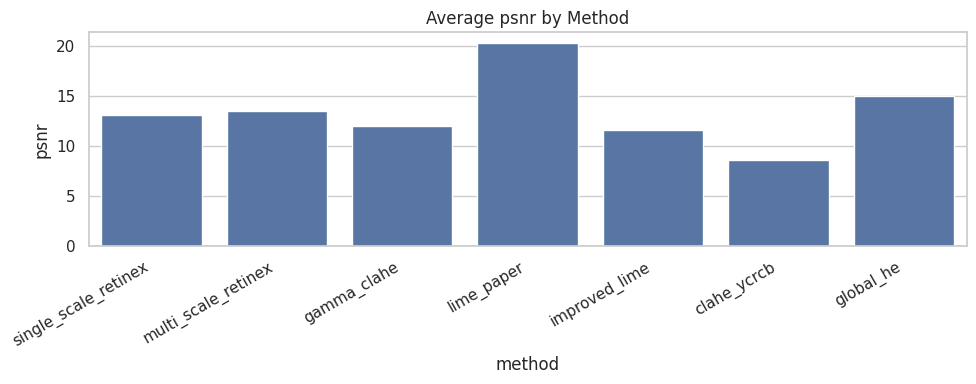

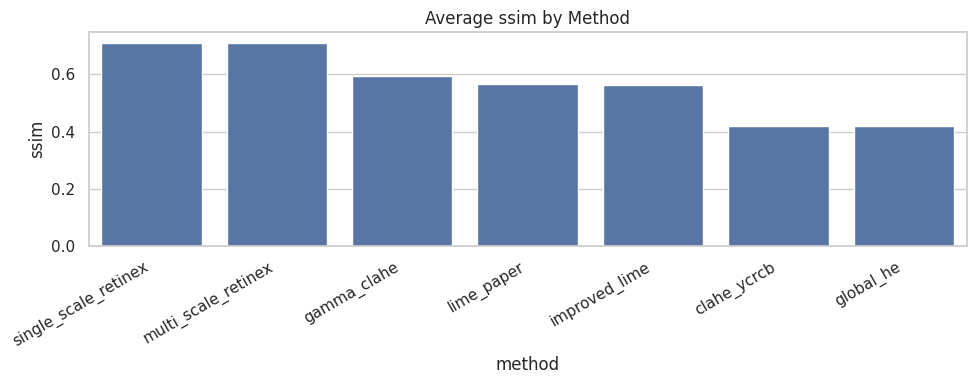

In [39]:
plot_metrics = ["brightness", "contrast", "entropy", "brightness_gain", "contrast_gain", "runtime_ms"]
if average_df["ssim"].notna().any():
    plot_metrics.extend(["psnr", "ssim"])

for metric in plot_metrics:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=average_df, x="method", y=metric)
    plt.title(f"Average {metric} by Method")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


# Part L - Discussion, Innovation, and Viva


## What came straight from the paper?

- Estimating the first illumination map as the max of the R, G, B channels.
- Refining that map with edge-preserving smoothing (the paper's structure-aware idea).
- Brightening by dividing out the illumination, with gamma controlling the strength.
- Showing the illumination maps as visual proof the method is doing what we claim.

## What did we add ourselves?

- A bilateral denoise before LIME, so we are not amplifying sensor noise along with the signal.
- Gamma chosen automatically from the input brightness instead of a fixed value.
- CLAHE on the luminance channel after LIME to bring back local contrast.

## What we expect to see

LIME should lift the dark regions while keeping structure better than plain histogram equalization. Improved LIME should look cleaner and punchier still, the trade-off being a little extra runtime from the denoise and CLAHE steps.


In [40]:
viva_questions = [
    ("Why did you select LIME?", "It is an IEEE TIP paper and directly solves low-light enhancement using illumination map estimation."),
    ("What is T_hat?", "It is the initial illumination map estimated as the maximum of R, G, and B channels at each pixel."),
    ("Why refine illumination?", "Raw illumination can contain noise and texture; refinement smooths illumination while preserving structure."),
    ("What is your innovation?", "We add denoising, adaptive gamma, and CLAHE after LIME."),
    ("How did you evaluate results?", "Using visual comparison, histograms, brightness, contrast, entropy, runtime, and PSNR/SSIM when references exist."),
]

for question, answer in viva_questions:
    print("Q:", question)
    print("A:", answer)
    print()


Q: Why did you select LIME?
A: It is an IEEE TIP paper and directly solves low-light enhancement using illumination map estimation.

Q: What is T_hat?
A: It is the initial illumination map estimated as the maximum of R, G, and B channels at each pixel.

Q: Why refine illumination?
A: Raw illumination can contain noise and texture; refinement smooths illumination while preserving structure.

Q: What is your innovation?
A: We add denoising, adaptive gamma, and CLAHE after LIME.

Q: How did you evaluate results?
A: Using visual comparison, histograms, brightness, contrast, entropy, runtime, and PSNR/SSIM when references exist.



## Student-Wise Contribution


In [41]:
contributions = {
    "Awais Tahir (232387) - Research and Algorithm": [
        "Selected and explained LIME paper",
        "Implemented LIME methodology",
        "Explained HE, CLAHE, Retinex, and illumination maps",
    ],
    "Zain Ul Abideen (232420) - Dataset and Evaluation": [
        "Handled image upload/dataset organization",
        "Implemented PSNR, SSIM, MSE, entropy, brightness, contrast, runtime",
        "Generated result tables and metric graphs",
    ],
    "Abeera Zainab (232997) - Visualization and Documentation": [
        "Created visual comparisons, histograms, CDF plots, and illumination maps",
        "Prepared viva discussion and output ZIP",
        "Maintained report-ready figures and explanations",
    ],
}

for student, tasks in contributions.items():
    print(student)
    for task in tasks:
        print(" -", task)
    print()


Awais Tahir (232387) - Research and Algorithm
 - Selected and explained LIME paper
 - Implemented LIME methodology
 - Explained HE, CLAHE, Retinex, and illumination maps

Zain Ul Abideen (232420) - Dataset and Evaluation
 - Handled image upload/dataset organization
 - Implemented PSNR, SSIM, MSE, entropy, brightness, contrast, runtime
 - Generated result tables and metric graphs

Abeera Zainab (232997) - Visualization and Documentation
 - Created visual comparisons, histograms, CDF plots, and illumination maps
 - Prepared viva discussion and output ZIP
 - Maintained report-ready figures and explanations



## Download Final Results


In [42]:
zip_path = Path("/content/lime_low_light_results.zip") if IN_COLAB else Path("lime_low_light_results.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for path in BASE_DIR.rglob("*"):
        if path.is_file():
            zipf.write(path, path.relative_to(BASE_DIR))

print("Created:", zip_path)
if IN_COLAB:
    files.download(str(zip_path))


Created: /content/lime_low_light_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# References

[1] X. Guo, Y. Li, and H. Ling, "LIME: Low-Light Image Enhancement via Illumination Map Estimation," *IEEE Transactions on Image Processing*, vol. 26, no. 2, pp. 982-993, 2017.  
[2] K. Zuiderveld, "Contrast Limited Adaptive Histogram Equalization," in *Graphics Gems IV*, Academic Press, 1994.  
[3] E. H. Land, "The Retinex Theory of Color Vision," *Scientific American*, 1977.  
[4] OpenCV Documentation, "Histograms - Histogram Equalization and CLAHE."  
[5] W. Wei, W. Wang, W. Yang, and J. Liu, "Deep Retinex Decomposition for Low-Light Enhancement," BMVC, 2018.
